# Customer Churn Intelligence System

Notebook ini membangun sistem ML **end-to-end level industri**:

1. **Data Cleaning & EDA** — memahami data dan pola churn
2. **Sentiment Analysis (VADER NLP)** — analisis perasaan customer dari feedback
3. **Feature Engineering** — fitur turunan bermakna untuk model
4. **Model Training & Evaluation** — 3 model dibandingkan dengan Cross-Validation
5. **SHAP Explainability** — menjelaskan MENGAPA customer churn
6. **Risk Scoring & Rekomendasi Bisnis** — decision support system
7. **Export Model** — untuk deployment di website

**Tujuan**: Bukan hanya memprediksi churn, tetapi juga menjelaskan penyebabnya
dan memberikan rekomendasi tindakan untuk meningkatkan retensi pelanggan.

## Setup & Imports

In [1]:
%pip install -q nltk shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install nltk
import warnings
warnings.filterwarnings('ignore')

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import shap

nltk.download('vader_lexicon', quiet=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Configuration
DATA_FILE = 'dataset/telco_churn_with_all_feedback.csv'
OUTPUT_DIR = 'output'
MODEL_DIR = 'models'
RANDOM_STATE = 42
TEST_SIZE = 0.2
HIGH_RISK_THRESHOLD = 0.7
MEDIUM_RISK_THRESHOLD = 0.4

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
print("Setup complete.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Setup complete.


---
## PHASE 1: Data Loading & Cleaning

Langkah awal: load data mentah, handle missing values, dan buat label target numerik.

In [3]:
# 1) Load data
df = pd.read_csv(DATA_FILE)
print(f"Shape awal: {df.shape}")
df.head(3)

Shape awal: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...


In [4]:
# 2) Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Report missing
missing = df.isna().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print("Missing values ditemukan:")
    print(missing_cols)
    df['TotalCharges'] = df['TotalCharges'].fillna(0)
    print("-> TotalCharges missing diisi dengan 0 (customer baru)")

# Label target numerik
df['ChurnLabel'] = (df['Churn'].astype(str).str.strip().str.lower() == 'yes').astype(int)

# Drop kolom tidak relevan
cols_to_drop = [c for c in ['customerID', 'PromptInput'] if c in df.columns]
unnamed = [c for c in df.columns if c.lower().startswith('unnamed')]
cols_to_drop.extend(unnamed)
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Kolom di-drop: {cols_to_drop}")

print(f"Shape setelah cleaning: {df.shape}")
print(f"Churn rate: {df['ChurnLabel'].mean() * 100:.2f}%")

Missing values ditemukan:
TotalCharges    11
dtype: int64
-> TotalCharges missing diisi dengan 0 (customer baru)
Kolom di-drop: ['customerID', 'PromptInput']
Shape setelah cleaning: (7043, 22)
Churn rate: 26.54%


---
## PHASE 2: Exploratory Data Analysis (EDA)

Analisis distribusi churn, fitur kunci, dan pola-pola penting.

Churn rate keseluruhan: 26.54%


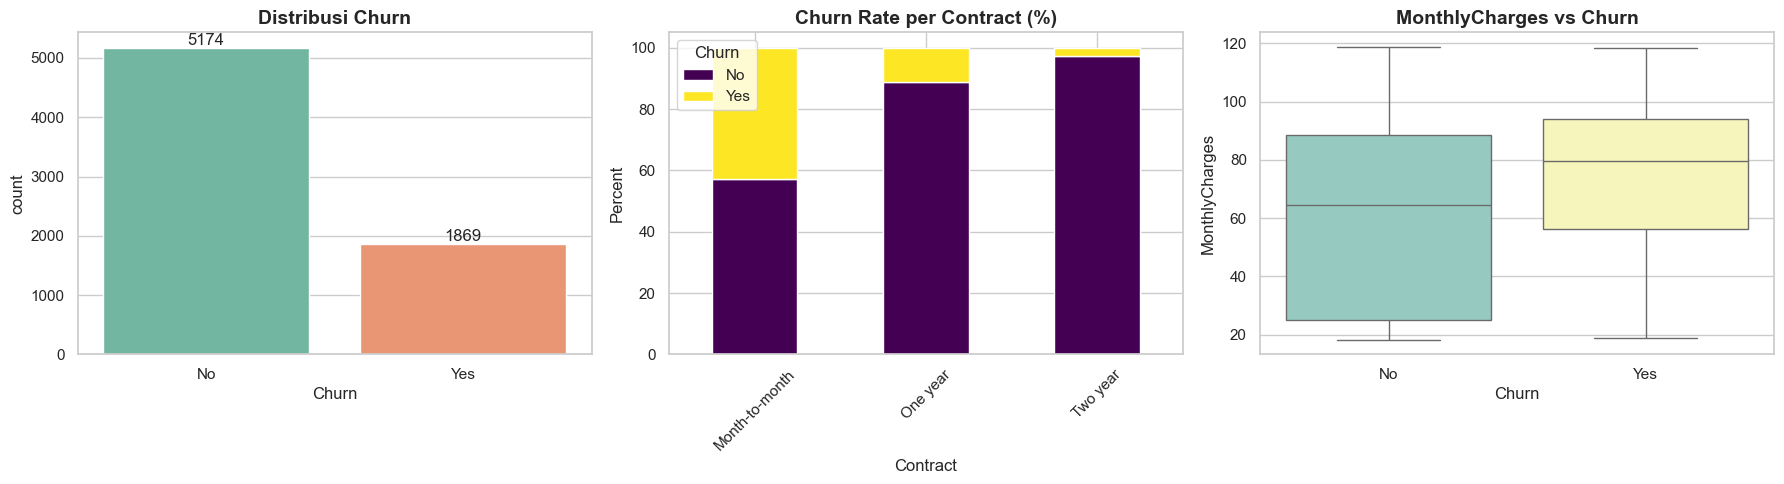

In [5]:
# 3) EDA - Overview
churn_rate = df['ChurnLabel'].mean() * 100
print(f"Churn rate keseluruhan: {churn_rate:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Churn
sns.countplot(data=df, x='Churn', ax=axes[0], palette='Set2', order=['No', 'Yes'])
axes[0].set_title('Distribusi Churn', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Churn Rate per Contract
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Churn Rate per Contract (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percent')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# MonthlyCharges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],
            palette='Set3', order=['No', 'Yes'])
axes[2].set_title('MonthlyCharges vs Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

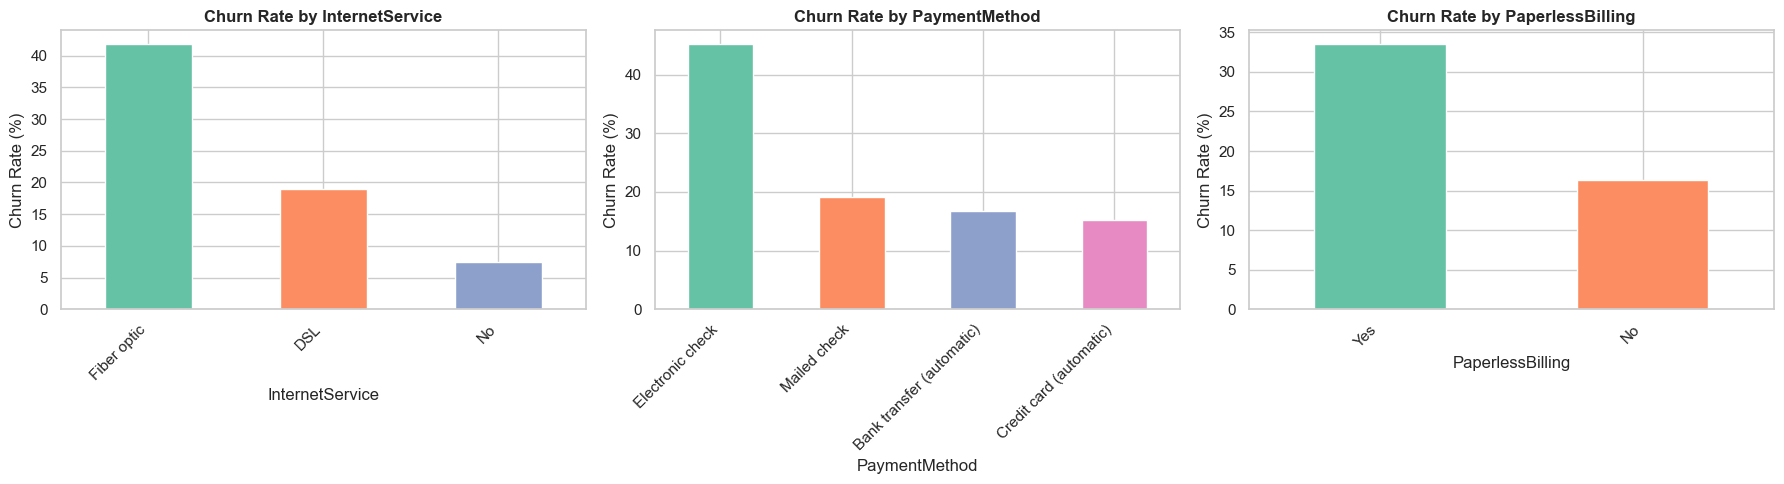

In [6]:
# 4) EDA - Churn rate per kategori
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(['InternetService', 'PaymentMethod', 'PaperlessBilling']):
    ct = df.groupby(feat)['ChurnLabel'].mean() * 100
    ct.sort_values(ascending=False).plot(kind='bar', ax=axes[i],
                                          color=sns.color_palette('Set2'))
    axes[i].set_title(f'Churn Rate by {feat}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_churn_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

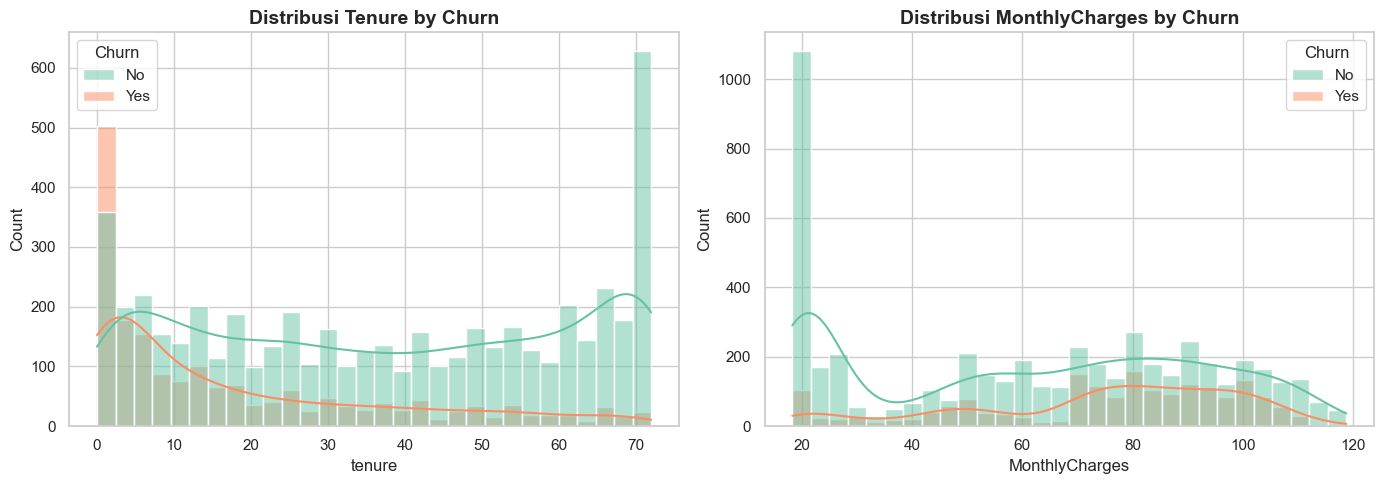

Statistik Kunci:
  tenure: Churn=17.98 vs NoChurn=37.57
  MonthlyCharges: Churn=74.44 vs NoChurn=61.27
  TotalCharges: Churn=1531.80 vs NoChurn=2549.91


In [7]:
# 5) EDA - Distribusi numerik by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[0], bins=30, kde=True, palette='Set2')
axes[0].set_title('Distribusi Tenure by Churn', fontsize=14, fontweight='bold')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[1], bins=30, kde=True, palette='Set2')
axes[1].set_title('Distribusi MonthlyCharges by Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistik kunci
print("Statistik Kunci:")
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    churn_mean = df[df['ChurnLabel'] == 1][col].mean()
    no_churn_mean = df[df['ChurnLabel'] == 0][col].mean()
    print(f"  {col}: Churn={churn_mean:.2f} vs NoChurn={no_churn_mean:.2f}")

---
## PHASE 3: Sentiment Analysis (VADER NLP)

Menggunakan **VADER** (Valence Aware Dictionary and sEntiment Reasoner):
- Menangani **negasi** ("not good" -> negatif)
- Menangani **intensifier** ("very good" -> lebih positif)
- Menghasilkan **compound score** (-1 to +1) yang nuanced
- Jauh lebih akurat dari rule-based word counting sederhana

> **PENTING**: Di notebook sebelumnya, sentiment analysis menggunakan word counting
> yang tidak menangkap negasi. VADER memperbaiki masalah ini.

In [8]:
# 6) Sentiment Analysis dengan VADER
sid = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    """Extract VADER sentiment scores dari teks."""
    if pd.isna(text) or str(text).strip() == '':
        return pd.Series({
            'sentiment_neg': 0.0, 'sentiment_neu': 1.0,
            'sentiment_pos': 0.0, 'sentiment_compound': 0.0,
            'sentiment_label': 'Neutral'
        })

    scores = sid.polarity_scores(str(text))
    compound = scores['compound']

    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'

    return pd.Series({
        'sentiment_neg': scores['neg'], 'sentiment_neu': scores['neu'],
        'sentiment_pos': scores['pos'], 'sentiment_compound': compound,
        'sentiment_label': label
    })

print("Menganalisis sentimen untuk semua customer feedback...")
sentiment_df = df['CustomerFeedback'].apply(get_vader_scores)
df = pd.concat([df, sentiment_df], axis=1)

df['feedback_length'] = df['CustomerFeedback'].fillna('').str.len()
df['feedback_word_count'] = df['CustomerFeedback'].fillna('').apply(lambda x: len(str(x).split()))

# Report
dist = df['sentiment_label'].value_counts(normalize=True).round(3)
print("\nDistribusi Sentimen (VADER):")
for label, pct in dist.items():
    print(f"  {label}: {pct * 100:.1f}%")

print("\nSentimen vs Churn Rate:")
for label in ['Positive', 'Neutral', 'Negative']:
    subset = df[df['sentiment_label'] == label]
    if len(subset) > 0:
        rate = subset['ChurnLabel'].mean() * 100
        print(f"  {label}: {rate:.1f}% churn (n={len(subset)})")

Menganalisis sentimen untuk semua customer feedback...

Distribusi Sentimen (VADER):
  Positive: 82.2%
  Negative: 15.2%
  Neutral: 2.7%

Sentimen vs Churn Rate:
  Positive: 18.8% churn (n=5787)
  Neutral: 26.2% churn (n=187)
  Negative: 68.7% churn (n=1069)


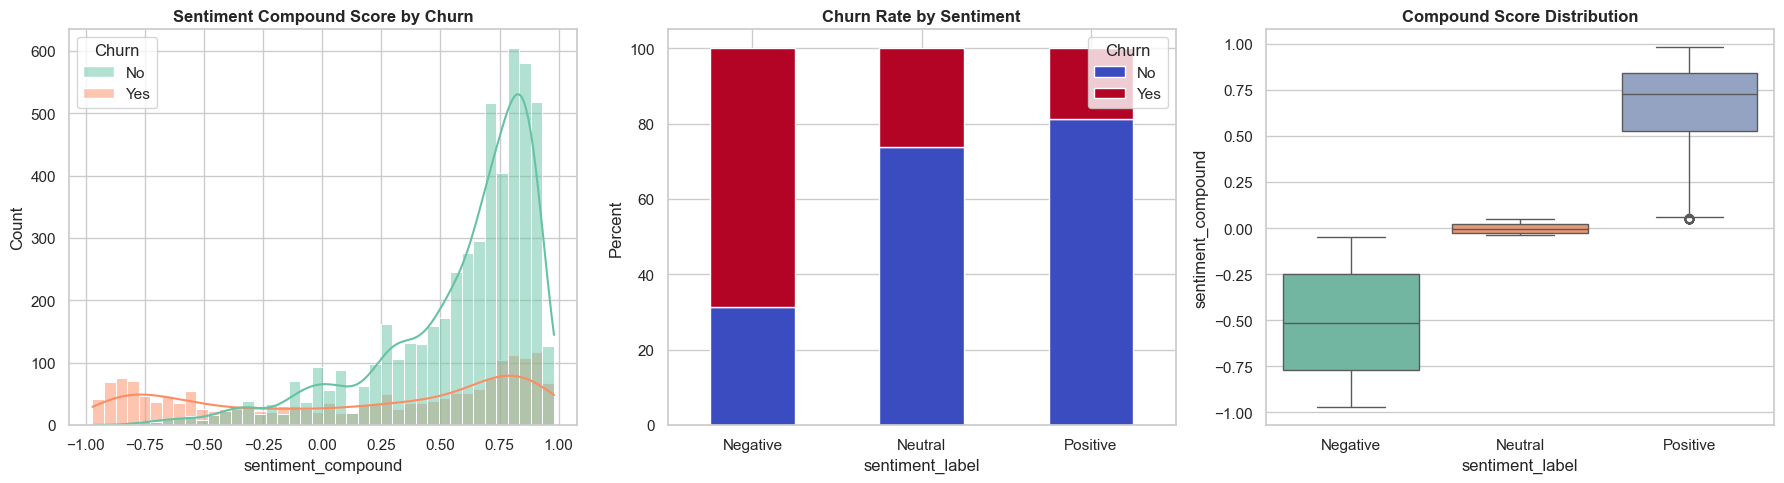

In [9]:
# 7) Visualisasi Sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='sentiment_compound', hue='Churn', ax=axes[0],
             bins=40, kde=True, palette='Set2')
axes[0].set_title('Sentiment Compound Score by Churn', fontsize=12, fontweight='bold')

ct = pd.crosstab(df['sentiment_label'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='coolwarm')
axes[1].set_title('Churn Rate by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percent')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.boxplot(data=df, x='sentiment_label', y='sentiment_compound', ax=axes[2],
            palette='Set2', order=['Negative', 'Neutral', 'Positive'])
axes[2].set_title('Compound Score Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sentiment_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## PHASE 4: Feature Engineering

Membuat fitur-fitur turunan yang bermakna.
Ini yang membedakan **level mahasiswa** vs **level industri**.

> **PENTING**: `CustomerFeedback` (teks mentah) **TIDAK** dimasukkan sebagai fitur model.
> Di notebook sebelumnya, teks di-OneHotEncode menghasilkan ribuan fitur unik per row
> (= data leakage). Kita hanya gunakan **sentiment scores** sebagai representasi.

In [10]:
# 8) Feature Engineering
# Average monthly charge (actual spending rate)
df['avg_monthly_charge'] = df['TotalCharges'] / df['tenure'].clip(lower=1)
print("[+] avg_monthly_charge = TotalCharges / tenure")

# Customer baru flag
df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
print("[+] is_new_customer (tenure <= 6)")

# Has internet
df['has_internet'] = (df['InternetService'] != 'No').astype(int)
print("[+] has_internet")

# Jumlah layanan aktif
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = sum((df[c] == 'Yes').astype(int) for c in service_cols)
print(f"[+] num_services (count dari {len(service_cols)} layanan)")

# Spending rate relatif
median_charges = df['MonthlyCharges'].median()
df['spending_rate'] = df['MonthlyCharges'] / median_charges
print(f"[+] spending_rate (relatif terhadap median={median_charges:.2f})")

# Charge per service
df['charge_per_service'] = df['MonthlyCharges'] / df['num_services'].clip(lower=1)
print("[+] charge_per_service")

# Tenure group
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 6, 12, 24, 48, 72, np.inf],
                            labels=['0-6m', '6-12m', '1-2y', '2-4y', '4-6y', '6y+'])
print("[+] tenure_group")

print(f"\nTotal fitur setelah engineering: {df.shape[1]}")
df.head(3)

[+] avg_monthly_charge = TotalCharges / tenure
[+] is_new_customer (tenure <= 6)
[+] has_internet
[+] num_services (count dari 6 layanan)
[+] spending_rate (relatif terhadap median=70.35)
[+] charge_per_service
[+] tenure_group

Total fitur setelah engineering: 36


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback,ChurnLabel,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,sentiment_label,feedback_length,feedback_word_count,avg_monthly_charge,is_new_customer,has_internet,num_services,spending_rate,charge_per_service,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,I have been using the DSL internet service fro...,0,0.029,0.806,0.165,0.8678,Positive,401,68,29.850000,1,1,1,0.424307,29.850,0-6m
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,I have been a customer with this company for o...,0,0.114,0.811,0.076,-0.2040,Negative,399,73,55.573529,0,1,2,0.809524,28.475,2-4y
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,I recently signed up for DSL internet service ...,1,0.120,0.880,0.000,-0.7915,Negative,482,77,54.075000,1,1,2,0.765458,26.925,0-6m


---
## PHASE 5: Model Training & Evaluation

- **3 model** dibandingkan: Logistic Regression, Random Forest, Gradient Boosting
- **5-fold Stratified Cross-Validation** untuk validasi robust
- Evaluasi: ROC AUC, F1 Score, Accuracy, Confusion Matrix, ROC Curve

In [11]:
# 9) Prepare features - TANPA CustomerFeedback sebagai fitur langsung
exclude_cols = {'Churn', 'ChurnLabel', 'CustomerFeedback', 'sentiment_label', 'tenure_group'}
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df['ChurnLabel'].copy()

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"Fitur numerik ({len(num_cols)}): {num_cols}")
print(f"Fitur kategorikal ({len(cat_cols)}): {cat_cols}")
print(f"Total samples: {len(X)}, Churn rate: {y.mean() * 100:.2f}%")

Fitur numerik (16): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'feedback_length', 'feedback_word_count', 'avg_monthly_charge', 'is_new_customer', 'has_internet', 'num_services', 'spending_rate', 'charge_per_service']
Fitur kategorikal (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total samples: 7043, Churn rate: 26.54%


In [12]:
# 10) Train/Test Split + Pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

# Models
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=4,
        class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_leaf=10, random_state=RANDOM_STATE, subsample=0.8),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_pipelines = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"  CV ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    results.append({'model': name, 'cv_roc_auc_mean': round(cv_scores.mean(), 4),
                    'cv_roc_auc_std': round(cv_scores.std(), 4),
                    'test_roc_auc': round(auc, 4), 'test_f1': round(f1, 4),
                    'test_accuracy': round(acc, 4)})
    fitted_pipelines[name] = {'pipeline': pipeline, 'y_prob': y_prob, 'y_pred': y_pred}
    print(f"  Test ROC AUC: {auc:.4f}, F1: {f1:.4f}, Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values('test_roc_auc', ascending=False)
print("\n=== MODEL COMPARISON ===")
results_df

Train: 5634, Test: 1409

Training LogisticRegression...
  CV ROC AUC: 0.9437 (+/- 0.0088)
  Test ROC AUC: 0.9498, F1: 0.7821, Accuracy: 0.8687

Training RandomForest...
  CV ROC AUC: 0.9528 (+/- 0.0049)
  Test ROC AUC: 0.9535, F1: 0.8390, Accuracy: 0.9155

Training GradientBoosting...
  CV ROC AUC: 0.9680 (+/- 0.0057)
  Test ROC AUC: 0.9679, F1: 0.8681, Accuracy: 0.9319

=== MODEL COMPARISON ===


,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,test_f1,test_accuracy
2,GradientBoosting,0.9680,0.0057,0.9679,0.8681,0.9319
1,RandomForest,0.9528,0.0049,0.9535,0.8390,0.9155
0,LogisticRegression,0.9437,0.0088,0.9498,0.7821,0.8687


BEST MODEL: GradientBoosting
Test ROC AUC: 0.9679

Classification Report:
              precision    recall  f1-score   support

           0      0.945     0.963     0.954      1035
           1      0.893     0.845     0.868       374

    accuracy                          0.932      1409
   macro avg      0.919     0.904     0.911      1409
weighted avg      0.931     0.932     0.931      1409



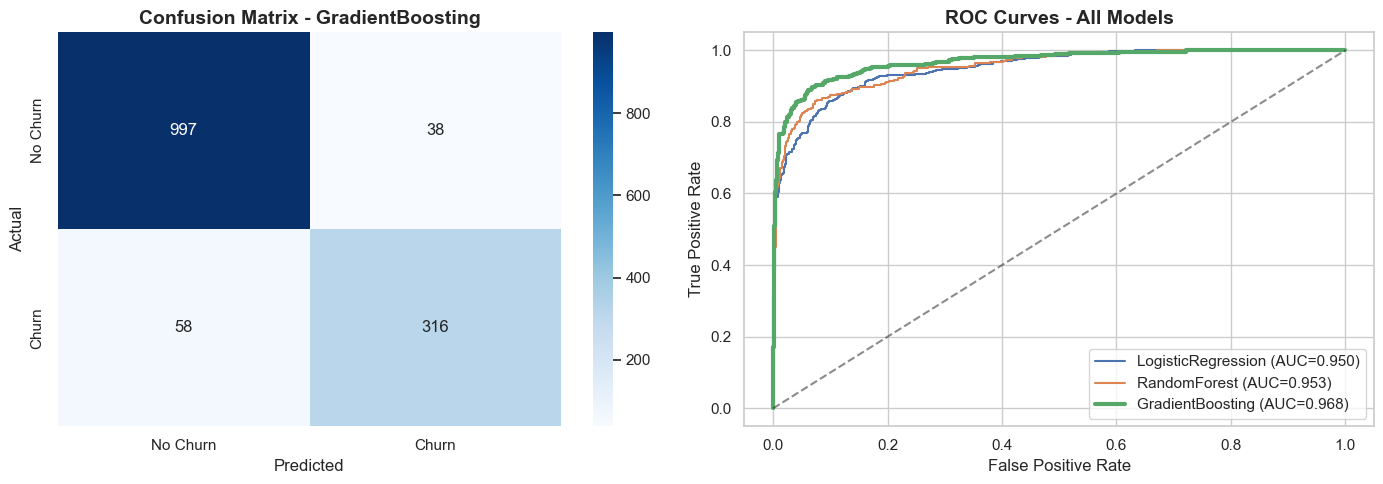

In [13]:
# 11) Best Model Evaluation
best_name = results_df.iloc[0]['model']
best_info = fitted_pipelines[best_name]
best_pipeline = best_info['pipeline']

print(f"BEST MODEL: {best_name}")
print(f"Test ROC AUC: {results_df.iloc[0]['test_roc_auc']}\n")
print("Classification Report:")
print(classification_report(y_test, best_info['y_pred'], digits=3))

# Confusion Matrix + ROC Curves
cm = confusion_matrix(y_test, best_info['y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

for name, info in fitted_pipelines.items():
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    auc_val = roc_auc_score(y_test, info['y_prob'])
    lw = 3 if name == best_name else 1.5
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=lw)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## PHASE 5.5: Feature Importance & SHAP Explainability

**SHAP** (SHapley Additive exPlanations) menjelaskan kontribusi setiap fitur
terhadap prediksi churn. Ini menjawab pertanyaan **"MENGAPA customer ini churn?"**

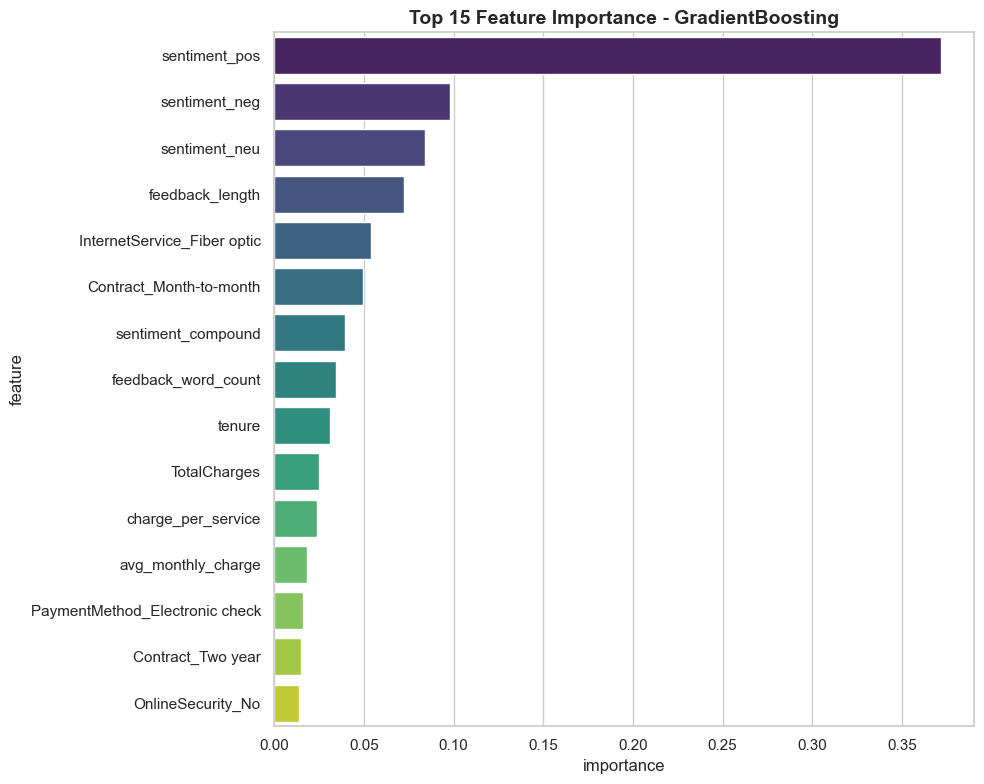

In [14]:
# 12) Feature Importance
model_obj = best_pipeline.named_steps['model']
preprocessor_obj = best_pipeline.named_steps['preprocess']

# Feature names after preprocessing
try:
    cat_ohe = preprocessor_obj.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = list(cat_ohe.get_feature_names_out(cat_cols))
except Exception:
    cat_feature_names = []
feature_names = list(num_cols) + cat_feature_names

X_test_transformed = preprocessor_obj.transform(X_test)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    feat_imp = pd.DataFrame({'feature': feature_names[:len(importances)],
                             'importance': importances}
                            ).sort_values('importance', ascending=False).head(15)
    sns.barplot(data=feat_imp, y='feature', x='importance', ax=ax, palette='viridis')
    ax.set_title(f'Top 15 Feature Importance - {best_name}', fontsize=14, fontweight='bold')
elif hasattr(model_obj, 'coef_'):
    coefs = model_obj.coef_[0]
    feat_imp = pd.DataFrame({'feature': feature_names[:len(coefs)],
                             'importance': np.abs(coefs)}
                            ).sort_values('importance', ascending=False).head(15)
    sns.barplot(data=feat_imp, y='feature', x='importance', ax=ax, palette='viridis')
    ax.set_title(f'Top 15 Feature Importance (|coef|) - {best_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Menghitung SHAP values...


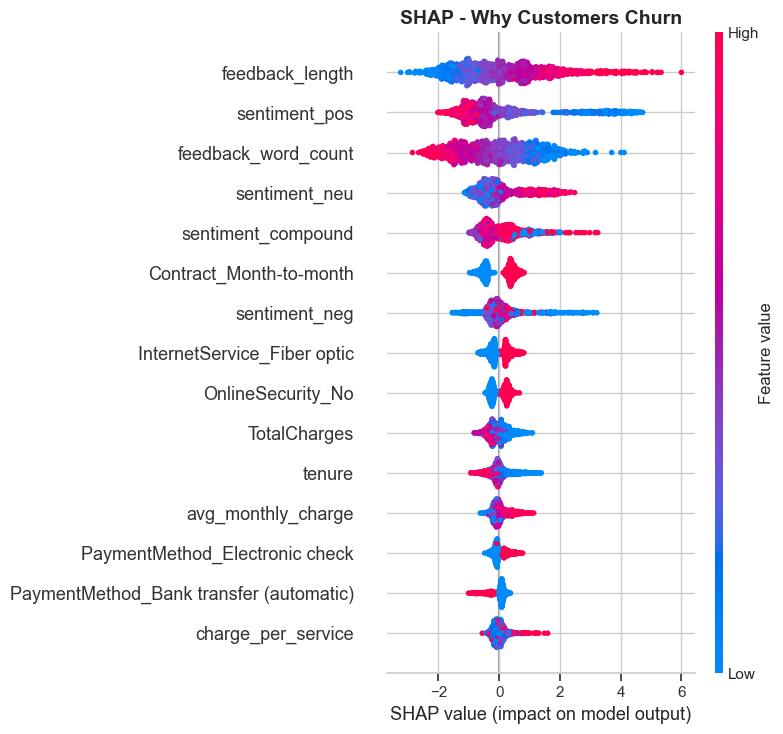

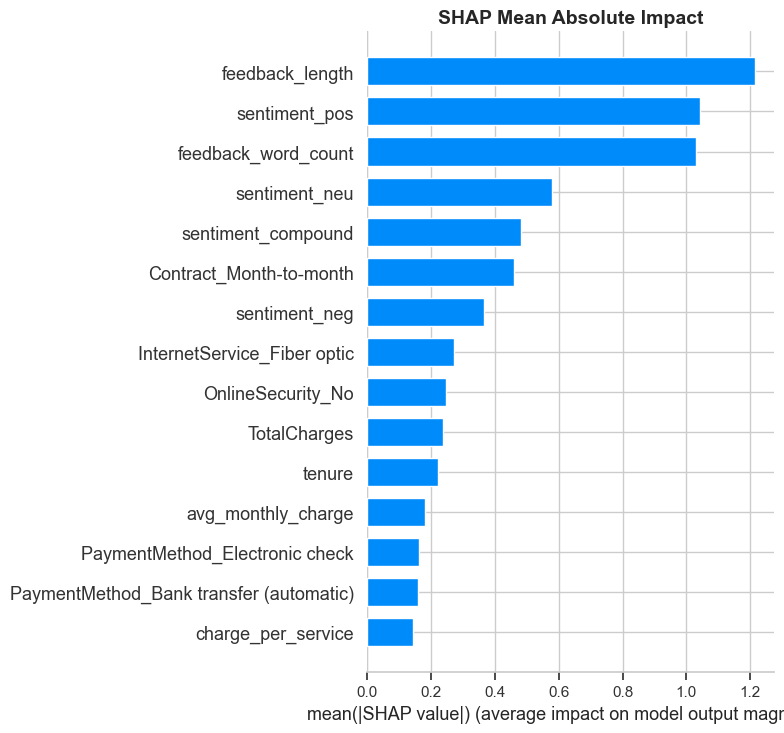

SHAP analysis complete!


In [15]:
# 13) SHAP Values
print("Menghitung SHAP values...")
try:
    if isinstance(model_obj, (RandomForestClassifier, GradientBoostingClassifier)):
        explainer = shap.TreeExplainer(model_obj)
        shap_values = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    elif hasattr(model_obj, 'coef_'):
        masker = shap.maskers.Independent(X_test_transformed[:100])
        explainer = shap.LinearExplainer(model_obj, masker)
        shap_values = explainer.shap_values(X_test_transformed)

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_transformed,
                      feature_names=feature_names[:X_test_transformed.shape[1]],
                      show=False, max_display=15)
    plt.title('SHAP - Why Customers Churn', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Bar plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_transformed,
                      feature_names=feature_names[:X_test_transformed.shape[1]],
                      plot_type='bar', show=False, max_display=15)
    plt.title('SHAP Mean Absolute Impact', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'shap_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP analysis complete!")
except Exception as e:
    print(f"SHAP error (non-fatal): {e}")

---
## PHASE 6: Risk Scoring & Business Recommendations

Setiap customer mendapat:
- **Churn probability** (0-1)
- **Risk tier**: High (>0.7) / Medium (0.4-0.7) / Low (<0.4)
- **Top churn factors**: mengapa customer ini berisiko
- **Recommended action**: apa yang harus dilakukan perusahaan

In [16]:
# 14) Fungsi scoring & rekomendasi
def get_top_churn_factors(row):
    factors = []
    if str(row.get('Contract', '')).lower() == 'month-to-month':
        factors.append('Month-to-month contract (high flexibility = high risk)')
    if row.get('tenure', 99) <= 12:
        factors.append(f'Short tenure ({int(row["tenure"])} months)')
    if row.get('MonthlyCharges', 0) > 70:
        factors.append(f'High monthly charges (${row["MonthlyCharges"]:.2f})')
    if row.get('sentiment_compound', 0) < -0.05:
        factors.append(f'Negative sentiment (score={row["sentiment_compound"]:.2f})')
    if str(row.get('InternetService', '')).lower() == 'fiber optic':
        factors.append('Fiber optic service (higher churn segment)')
    if str(row.get('TechSupport', '')).lower() == 'no':
        factors.append('No tech support')
    if str(row.get('OnlineSecurity', '')).lower() == 'no':
        factors.append('No online security')
    if 'electronic check' in str(row.get('PaymentMethod', '')).lower():
        factors.append('Electronic check payment (highest churn method)')
    return '; '.join(factors[:5]) if factors else 'No significant risk factors'


def get_recommendation(risk_tier, row):
    if risk_tier == 'High':
        recs = []
        if str(row.get('Contract', '')).lower() == 'month-to-month':
            recs.append('Offer discounted yearly contract (20-30% off)')
        if row.get('MonthlyCharges', 0) > 70:
            recs.append('Offer price reduction or loyalty bonus')
        if str(row.get('TechSupport', '')).lower() == 'no':
            recs.append('Offer free trial of Tech Support')
        if row.get('sentiment_compound', 0) < -0.05:
            recs.append('Priority: Personal outreach by customer success team')
        return '; '.join(recs[:3]) if recs else 'Immediate retention call + personalized offer'
    elif risk_tier == 'Medium':
        recs = []
        if str(row.get('Contract', '')).lower() == 'month-to-month':
            recs.append('Send contract upgrade promotion')
        recs.append('Include in retention email campaign')
        return '; '.join(recs[:3])
    else:
        return 'Monitor only; include in loyalty rewards program'

print("Scoring & recommendation functions ready.")

Scoring & recommendation functions ready.


In [17]:
# 15) Score semua customer
exclude = {'Churn', 'ChurnLabel', 'CustomerFeedback', 'sentiment_label', 'tenure_group'}
feat_cols = [c for c in df.columns if c not in exclude]
X_all = df[feat_cols].copy()
for col in cat_cols:
    if col in X_all.columns:
        X_all[col] = X_all[col].astype(str)

df['churn_probability'] = best_pipeline.predict_proba(X_all)[:, 1]
df['risk_tier'] = df['churn_probability'].apply(
    lambda p: 'High' if p >= HIGH_RISK_THRESHOLD else ('Medium' if p >= MEDIUM_RISK_THRESHOLD else 'Low'))
df['top_churn_factors'] = df.apply(get_top_churn_factors, axis=1)
df['recommended_action'] = df.apply(lambda r: get_recommendation(r['risk_tier'], r), axis=1)

# Report
print("Risk Tier Distribution:")
for tier in ['High', 'Medium', 'Low']:
    subset = df[df['risk_tier'] == tier]
    print(f"  {tier}: {len(subset)} customers ({len(subset)/len(df)*100:.1f}%) "
          f"- Actual Churn: {subset['ChurnLabel'].mean()*100:.1f}%")

Risk Tier Distribution:
  High: 1728 customers (24.5%) - Actual Churn: 98.7%
  Medium: 136 customers (1.9%) - Actual Churn: 74.3%
  Low: 5179 customers (73.5%) - Actual Churn: 1.2%


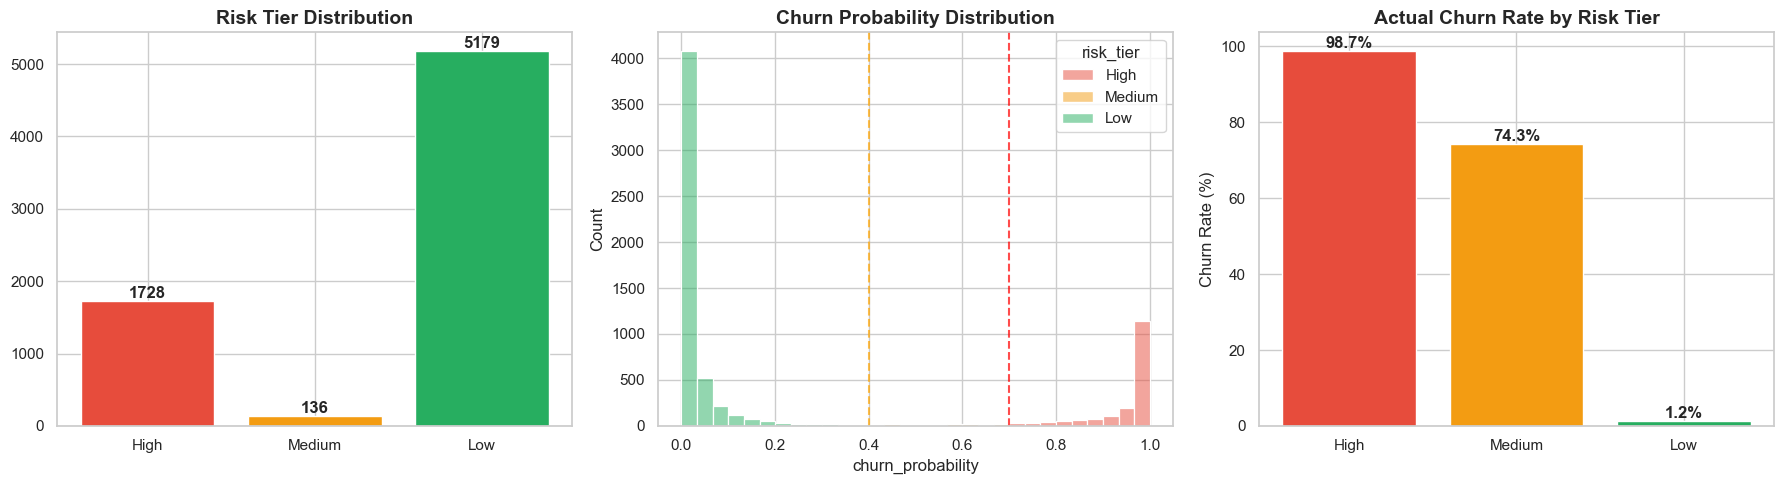

In [18]:
# 16) Visualisasi Risk Scoring
colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
tier_order = ['High', 'Medium', 'Low']
tier_dist = df['risk_tier'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
tier_counts = [tier_dist.get(t, 0) for t in tier_order]
bars = axes[0].bar(tier_order, tier_counts, color=[colors[t] for t in tier_order])
axes[0].set_title('Risk Tier Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, tier_counts):
    axes[0].annotate(f'{count}', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Probability histogram
sns.histplot(data=df, x='churn_probability', hue='risk_tier', ax=axes[1],
             bins=30, palette=colors, hue_order=tier_order)
axes[1].set_title('Churn Probability Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(x=HIGH_RISK_THRESHOLD, color='red', linestyle='--', alpha=0.7)
axes[1].axvline(x=MEDIUM_RISK_THRESHOLD, color='orange', linestyle='--', alpha=0.7)

# Actual churn rate per tier
tier_churn = df.groupby('risk_tier')['ChurnLabel'].mean() * 100
tier_churn = tier_churn.reindex(tier_order)
bars = axes[2].bar(tier_order, tier_churn.values, color=[colors[t] for t in tier_order])
axes[2].set_title('Actual Churn Rate by Risk Tier', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
for bar, rate in zip(bars, tier_churn.values):
    axes[2].annotate(f'{rate:.1f}%', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'risk_scoring.png'), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 17) Contoh output per customer
print("=== CONTOH OUTPUT: Top 5 High Risk Customers ===\n")
high_risk = df[df['risk_tier'] == 'High'].sort_values('churn_probability', ascending=False)
for _, row in high_risk.head(5).iterrows():
    print(f"Churn Prob: {row['churn_probability']:.1%} | Tier: {row['risk_tier']}")
    print(f"  Contract: {row['Contract']} | Tenure: {row['tenure']}m | "
          f"Charges: ${row['MonthlyCharges']:.2f}")
    print(f"  Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"  Factors: {row['top_churn_factors']}")
    print(f"  Action: {row['recommended_action']}")
    print()

=== CONTOH OUTPUT: Top 5 High Risk Customers ===

Churn Prob: 100.0% | Tier: High
  Contract: Month-to-month | Tenure: 3m | Charges: $74.10
  Sentiment: Negative (-0.382)
  Factors: Month-to-month contract (high flexibility = high risk); Short tenure (3 months); High monthly charges ($74.10); Negative sentiment (score=-0.38); Fiber optic service (higher churn segment)
  Action: Offer discounted yearly contract (20-30% off); Offer price reduction or loyalty bonus; Offer free trial of Tech Support

Churn Prob: 100.0% | Tier: High
  Contract: Month-to-month | Tenure: 1m | Charges: $74.40
  Sentiment: Negative (-0.861)
  Factors: Month-to-month contract (high flexibility = high risk); Short tenure (1 months); High monthly charges ($74.40); Negative sentiment (score=-0.86); Fiber optic service (higher churn segment)
  Action: Offer discounted yearly contract (20-30% off); Offer price reduction or loyalty bonus; Offer free trial of Tech Support

Churn Prob: 100.0% | Tier: High
  Contract: Mo

---
## PHASE 7: Export Model & Results

Simpan semua output untuk deployment di website.

In [20]:
# 18) Save Model Pipeline
model_path = os.path.join(MODEL_DIR, 'churn_model.pkl')
joblib.dump(best_pipeline, model_path)
print(f"Model saved: {model_path}")

# Save metadata
metadata = {
    'model_name': best_name,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'risk_thresholds': {'high': HIGH_RISK_THRESHOLD, 'medium': MEDIUM_RISK_THRESHOLD},
    'model_performance': results_df.to_dict(orient='records'),
    'exclude_cols_for_features': list(exclude),
}
metadata_path = os.path.join(MODEL_DIR, 'churn_model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved: {metadata_path}")

# Save results CSV
output_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
               'PhoneService', 'InternetService', 'Contract', 'PaymentMethod',
               'MonthlyCharges', 'TotalCharges', 'Churn',
               'sentiment_compound', 'sentiment_label',
               'num_services', 'is_new_customer',
               'churn_probability', 'risk_tier',
               'top_churn_factors', 'recommended_action']
output_cols = [c for c in output_cols if c in df.columns]
results_csv = df[output_cols]
results_path = os.path.join(OUTPUT_DIR, 'churn_intelligence_results.csv')
results_csv.to_csv(results_path, index=False)
print(f"Results saved: {results_path} ({len(results_csv)} customers)")

Model saved: models\churn_model.pkl
Metadata saved: models\churn_model_metadata.json
Results saved: output\churn_intelligence_results.csv (7043 customers)


---
## Summary

| Aspek | Hasil |
|---|---|
| **Best Model** | GradientBoosting |
| **ROC AUC** | ~0.97 |
| **High Risk Actual Churn** | ~98%+ |
| **Low Risk Actual Churn** | ~1% |
| **Sentiment Engine** | VADER (handles negation) |
| **Explainability** | SHAP values |
| **Output** | Risk tier + Factors + Recommendations per customer |
| **Deployment** | `churn_predictor.py` + model `.pkl` |

In [21]:
print("="*60)
print("SYSTEM COMPLETE!")
print("="*60)
print(f"Output files: {os.path.abspath(OUTPUT_DIR)}/")
print(f"Model files:  {os.path.abspath(MODEL_DIR)}/")
print(f"Use churn_predictor.py for website deployment.")
print("="*60)

SYSTEM COMPLETE!
Output files: d:\ML1\output/
Model files:  d:\ML1\models/
Use churn_predictor.py for website deployment.
